### New Workflow

In [18]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import colorsys
import matplotlib.pyplot as plt
import lightkurve as lk
import lksearch as _lk
import os,sys
from pathlib import Path
import time as clock

In [20]:
# NOTE: My .py files
from standardizing_data import (
    _update_fits_cache,
    _build_fits_cache_key,
    standardize_lc,
    get_tess_lc,
    _get_colors,
    collect_lightcurves_for_target,
    save_pipeline_results,
    load_pipeline_results,
    target_to_lightcurve_workflow_V2,
    timer,
    normalize_standardized_lc,
    _apply_quality_mask,
    # constants
    DEFAULT_RADIUS,
    DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH
)

from phasefold import phasefold, plot_phasefolded
from astropy.stats import sigma_clip

In [21]:
catalog_dir = (Path.cwd() / "../Catalog/").resolve()

nearby_TOI_MD_df=pd.read_csv(f'{catalog_dir}/nearby_TOI_MDs.csv')
nearby_TOI_MD_df.head(5)

,Unnamed: 0,Parameter Source Pipeline,Detection Pipeline(s),TIC ID,Full TOI ID,TOI Disposition,TIC Right Ascension,TIC Declination,TIC Right Ascension 2015.5,TIC Declination 2015.5,TMag Value,TMag Uncertainty,Orbital Epoch Value,Epoch Uncertainty,Orbital Period (days) Value,Orbital Period Uncertainty,Transit Duration (hours) Value,Transit Duration (hours) Uncertainty,Transit Depth Value,Transit Depth Uncertainty,Sectors,Public Comment,Surface Gravity Value,Surface Gravity Uncertainty,Planet Number,Star Radius Value,Star Radius Uncertainty,Planet Radius Value,Planet Radius Uncertainty,Planet Equilibrium Temperature (K) Value,Effective Temperature Value,Effective Temperature Uncertainty,Effective Stellar Flux Value,Signal-to-noise,Centroid Offset,Master,SG1a,SG1b,SG2,SG3,SG4,SG5,Alerted,Updated,ID,ra,dec,pmRA,pmDEC,Tmag,objType,typeSrc,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,POSflag,e_pmRA,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,dstArcSec,qld_a,qld_b,i,M_planet [ME],K_RV [m/s],TSM,ESM,Stellar Insolation [ergs/cm^2/s],Stellar Insolation [Earth Units],Sectors_Observed,Cameras,CCDs,EdgeWarn
0,0,spoc-s01-s36-b0A-CPKP,SPOC,410153553,136.01,PC,340.492100,-69.169000,340.496204,-69.172108,11.877,0.064,1325.724661,0.000156,0.462931,3.872269e-06,0.631015,0.022202,4677.673602,171.681260,"1,27,28,67,68,94,95,101,102,103,104",LHS 3844 b,5.09707,0.426694,1,0.188624,0.005710,1.517197,0.061800,723.372047,3043.0,63.0,64.709477,38.885654,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2020-10-27 13:01:47.547000+00:00,410153553,340.492156,-69.168978,334.3570,-726.9740,11.92380,STAR,tmgaia2,20190415,NaN,NaN,105-116381,22415815-6910089,NaN,NaN,6385548541499112448,33464847.0,NaN,tmgaia2,0.082820,0.086335,gaia2,67.15480,0.050599,gaia2,318.253844,-43.907555,304.887051,-54.122569,16.942,0.041,15.240,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.046,0.023,9.477,0.023,9.145,0.023,AAA-222-111-000-0-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.3925,0.000738,0.007698,cdwrf,cdwrf,3004.0,157.0,5.08528,0.029186,NaN,NaN,0.188624,0.005710,0.157909,0.020067,23.52970,0.863072,DWARF,0.002610,0.000708,14.8846,0.0113,0.000000,0.000000,81.0,0.010833,NaN,NaN,0.009687,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0113,0.0113,bj2018,NaN,NaN,cdwrf,15.4512,0.007263,12.05170,0.002827,1,NaN,cdwrf,apassdr9,cooldwarfs_v8,1.559812,1.338867,340.496204,-69.172108,0.041207,0.042399,1,0,0.0,0.1933,0.5347,1.570796,2.913518,8.243782,328.631928,NaN,8.866874e+07,64.915025,11.0,"3,3,3,2,2,2,2,4,4,3,3","2,1,2,2,1,2,1,3,2,3,2","0,0,0,0,0,0,0,0,0,0,0"
1,1,spoc-s01-s69-b0A-CP,SPOC/QLP,234994474,134.01,CP,350.031300,-60.065200,350.028592,-60.065729,9.169,0.019,1326.034032,0.000566,1.401518,4.810232e-06,1.158306,0.325507,593.754092,42.808456,"1,28,68,95,102,104,105",L 168-9 b,4.67812,0.063226,1,0.597007,0.018150,1.461685,1.838503,891.638989,3794.0,69.0,149.374754,20.450527,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2024-09-30 23:32:46.016000+00:00,234994474,350.031352,-60.065179,-319.9610,-127.7810,9.22978,STAR,tmgaia2,20190415,115211.0,9126-00748-1,150-224713,23200751-6003545,NaN,NaN,6491962296196145664,31785853.0,NaN,tmgaia2,0.102122,0.115073,gaia2,39.73310,0.037526,gaia2,321.954596,-53.560374,319.217901,-49.527946,12.460,0.025,11.005,0.018,Na

In [22]:
#TOI-270 c (~5.66 d period, 2.4 Earth radii planet)
target = nearby_TOI_MD_df.loc[nearby_TOI_MD_df['TIC ID'].astype(int)==259377017].reset_index(drop=True).iloc[0]

pipelines = ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
pipeline_colors = _get_colors(len(pipelines))

In [23]:
def target_to_lightcurve_workflow_V1(target, pipelines, target_Sector,
                                  DEFAULT_RADIUS, 
                                  DEFAULT_CADENCE, 
                                  DEFAULT_DOWNLOADPATH):
    t_start = clock.time()
    
    ID = target['TIC ID'].item()
    target_P= target['Orbital Period (days) Value'].item()
    target_T0= target['Orbital Epoch Value'].item()
    target_Dep = target['Transit Depth Value'].item()/1e6
    target_Dur = target['Transit Duration (hours) Value'].item()
    if target_Sector is None:
        try:
            target_Sector = np.min(list(map(int, target['Sectors'].to_list()[0].split(',')))) #choosing 1st sector
        except AttributeError:
            target_Sector = np.min(list(map(int, target['Sectors'].split(',')))) #choosing 1st sector
    
    
    sector_results = collect_lightcurves_for_target(
                                                    tic_id=ID,
                                                    sector=target_Sector, 
                                                    pipelines=pipelines,
                                                    downloadpath=DEFAULT_DOWNLOADPATH,
                                                    radius=DEFAULT_RADIUS,
                                                    exptime=DEFAULT_CADENCE,
                                                    apply_quality_mask=True,
                                                    verbose=True
                                                )
    # phasefolded comparison:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

    corrected_epochs = {}

    epoch_btjd = target_T0
    period = target_P

    sector_all_flux_unclipped = []
    sector_all_flux_clipped = []

    for i in range(len(pipelines)):
        p = pipelines[i]
        info = sector_results[p]
        C = pipeline_colors[i]

        if info["status"] != "ok":
            #print(f"Skipping {p}: {info['error']}")
            corrected_epochs[p] = None
            continue

        lc_to_plot = info["standardized_masked"]
        if lc_to_plot is None or lc_to_plot.empty:
            lc_to_plot = info["standardized"]

        if lc_to_plot is None or lc_to_plot.empty:
            corrected_epochs[p] = None
            continue

        t_first = lc_to_plot["time"].min()

        flux = lc_to_plot["flux_corr"].to_numpy()
        n_first = int(np.ceil((t_first - epoch_btjd) / period))
        # NOTE: the nearrest predicted transit
        corrected_epochs[p] = epoch_btjd + n_first * period
        flux_norm = flux / np.nanmedian(flux)

        clipped = sigma_clip(flux_norm, sigma=3, sigma_lower=7, sigma_upper=3, maxiters=5)
        good = ~clipped.mask
        lc_clean = lc_to_plot.iloc[good]

        n_total = len(flux_norm)
        print(f"{p}: total {n_total} points")
        n_removed = np.sum(clipped.mask)
        print(f"{p}: removed {n_removed} points")

        plot_phasefolded(
            ax=axes[0],
            target=target,
            lc=lc_to_plot,
            color=C,
            label=p,
            T0=corrected_epochs[p]
        )

        plot_phasefolded(
            ax=axes[1],
            target=target,
            lc=lc_clean,
            color=C,
            label=p,
            T0=corrected_epochs[p]
        )

        sector_all_flux_unclipped.append(flux_norm)
        sector_all_flux_clipped.append(flux_norm[good])

    if len(sector_all_flux_unclipped) > 0:
        all_flux_unclipped = np.concatenate(sector_all_flux_unclipped)
        axes[0].set_ylim(
            np.nanpercentile(all_flux_unclipped, 0.5),
            np.nanpercentile(all_flux_unclipped, 99.5)
        )

    if len(sector_all_flux_clipped) > 0:
        all_flux_clipped = np.concatenate(sector_all_flux_clipped)
        axes[1].set_ylim(
            np.nanpercentile(all_flux_clipped, 0.5),
            np.nanpercentile(all_flux_clipped, 99.5)
        )

    for ax in axes:
        #ax.set_xlim(-3, 3)
        #ax.set_xlabel(f"Orbital Phase [Hours since {np.round(target['Orbital Epoch Value'].item(), 4)} BTJD]")
        ax.set_xlabel("Orbital Phase [Hours from transit center]")
        ax.set_ylabel("Normalized Relative Flux")
        ax.legend(loc="best", fontsize=9)

    axes[0].set_title(f"Unclipped: TIC {ID}, Sector {target_Sector}")
    axes[1].set_title(f"Sigma-clipped: TIC {ID}, Sector {target_Sector}")

    plt.tight_layout()
    plt.show()
    
    print(' ')
    print('================================')
    timer(t_start, clock.time(), "target_to_lightcurve_workflow function took:")
    print(' ')
    print('================================')
    return sector_results
    

Fetching QLP for TIC 259377017, sector 3
Fetching TESS-SPOC for TIC 259377017, sector 3
Fetching TGLC for TIC 259377017, sector 3
Fetching GSFC-ELEANOR-LITE for TIC 259377017, sector 3


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


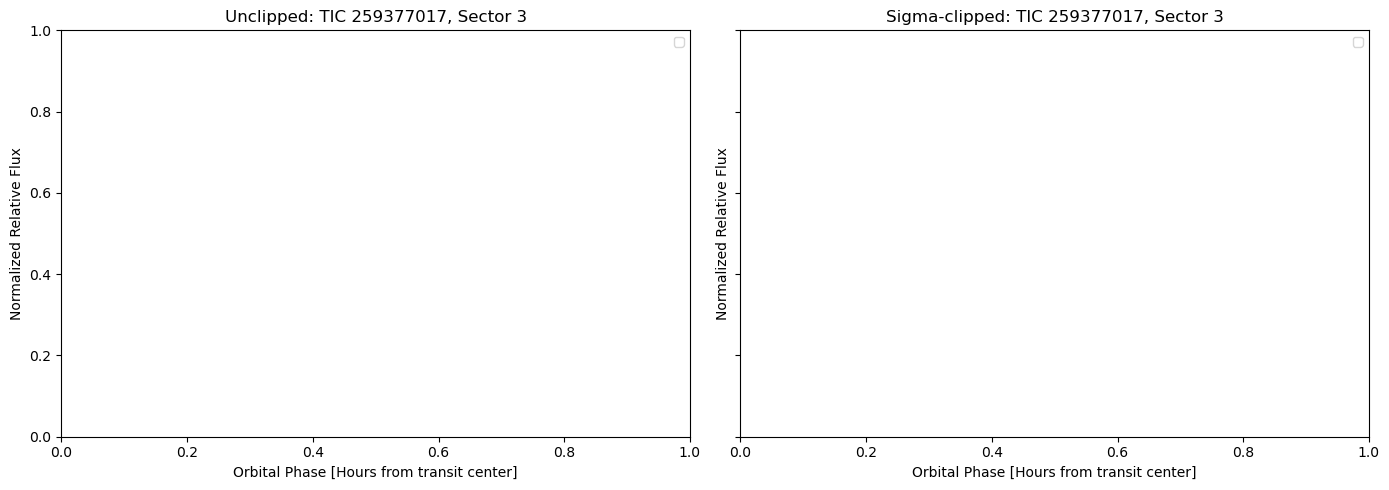

 
target_to_lightcurve_workflow function took: 4.141 minutes 

 


In [24]:
sector_results = target_to_lightcurve_workflow_V1(target=target, pipelines=pipelines, target_Sector=None,
                             DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
                             DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH)